# UE transfer between cells — load shift

5 eMBB UEs start at **gNB-0**.  Every 2 s one UE is manually transferred to **gNB-1**.  
Each transfer drops gNB-0 load by 0.15 and raises gNB-1 by 0.15.

| Step | UEs @ gNB-0 | UEs @ gNB-1 | gNB-0 load | gNB-1 load |
|:----:|:-----------:|:-----------:|:----------:|:----------:|
|  0   |      5      |      0      |   0.75     |   0.00     |
|  1   |      4      |      1      |   0.60     |   0.15     |
|  2   |      3      |      2      |   0.45     |   0.30     |
|  3   |      2      |      3      |   0.30     |   0.45     |
|  4   |      1      |      4      |   0.15     |   0.60     |

In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-chech')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenario_creator import create_multignb_env

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Ready')

Ready


## Configuration

In [2]:
TICK_S       = 0.001   # 1 ms → cell capacity ≈ 85 Mbps → 12 Mbps UE uses 15/100 PRBs
WARMUP_S     = 1.0     # steady-state before first transfer
HOLD_S       = 2.0     # seconds between consecutive transfers
N_TRANSFERS  = 4       # transfer 4 UEs one by one; 1 UE remains at gNB-0
TAIL_S       = 2.0

SIMULATION_S  = WARMUP_S + N_TRANSFERS * HOLD_S + TAIL_S
N_TICKS       = int(SIMULATION_S / TICK_S)

# Tick of each transfer
TRANSFER_TICKS = [int((WARMUP_S + i * HOLD_S) / TICK_S) for i in range(N_TRANSFERS)]

GNB_CONFIGS = [
    {'id': 0, 'x':   0.0, 'y':   0.0, 'coverage_radius': 520.0, 'carrier_id': 0, 'n_prbs': 100},
    {'id': 1, 'x': 450.0, 'y':   0.0, 'coverage_radius': 520.0, 'carrier_id': 0, 'n_prbs': 100},
    {'id': 2, 'x': 225.0, 'y': 390.0, 'coverage_radius': 520.0, 'carrier_id': 0, 'n_prbs': 100},
]

print(f'Simulation: {SIMULATION_S:.1f} s  ({N_TICKS} ticks)')
print(f'Transfer ticks: {TRANSFER_TICKS}  (every {HOLD_S:.0f} s starting at t={WARMUP_S:.0f} s)')

Simulation: 11.0 s  (11000 ticks)
Transfer ticks: [1000, 3000, 5000, 7000]  (every 2 s starting at t=1 s)


## Create environment and UEs

UEs start stationary near gNB-0.  When transferred, they are also **repositioned** near gNB-1 so their
SINR stays high — otherwise a UE at 430 m from gNB-1 would use far more than 15 PRBs.

`packet_size = bit_rate × step_dt = 12 Mbps × 1 ms = 12 000 bits` → exactly **15 PRBs/tick** at high SINR.

In [3]:
env = create_multignb_env(
    rng=np.random.default_rng(0),
    n=4,
    slots_per_step=1,
    L1_level=False,
    gnb_configs=GNB_CONFIGS,
    step_dt=TICK_S,
    mobility_dt=TICK_S,
    radio_substeps=1,
    max_episode_steps=N_TICKS + 1,
    max_prbs_per_ue=None,
    max_handovers_per_ue_episode=0,   # disable automatic A3 HOs — we drive transfers manually
)

# 5 stationary eMBB UEs, all near gNB-0
UE_POS_G0 = [(20, 10), (30, -10), (10, -20), (40,  5), (25, 20)]
# Where to re-place each UE after it is transferred to gNB-1
UE_POS_G1 = [(430, 10), (440, -10), (420, -20), (435, 5), (445, 20)]

for (x, y) in UE_POS_G0:
    env.add_ue(
        x=float(x), y=float(y), vx=0., vy=0.,
        slice_type='eMBB',
        bit_rate=12e6,
        packet_size_bits=12_000.,
        traffic_model='fixed_packet_cbr',
    )

all_ues = env.get_all_ues()
print('Initial UE positions (all attached to gNB-0):')
for u in all_ues:
    print(f'  UE-{u.id}  ({u.x:.0f}, {u.y:.0f})  serving_gNB={u.serving_gnb}')

Initial UE positions (all attached to gNB-0):
  UE-0  (20, 10)  serving_gNB=0
  UE-1  (30, -10)  serving_gNB=0
  UE-2  (10, -20)  serving_gNB=0
  UE-3  (40, 5)  serving_gNB=0
  UE-4  (25, 20)  serving_gNB=0


## Run simulation

In [4]:
SAMPLE_EVERY   = 5     # record every 5 ms
SLICE_TYPES    = ('eMBB', 'URLLC', 'mMTC')

records        = []
transfer_log   = []    # (time_s, ue_id, from_gnb, to_gnb)
transfer_set   = set(TRANSFER_TICKS)
transfer_queue = list(range(N_TRANSFERS))  # UE indices to move, in order

for tick in range(N_TICKS):

    # ── manual transfer ──────────────────────────────────────────────────────
    if tick in transfer_set and transfer_queue:
        ue_idx  = transfer_queue.pop(0)
        ue      = all_ues[ue_idx]
        from_id = int(ue.serving_gnb)
        to_id   = 1
        # 1. Reposition UE physically close to gNB-1 so SINR stays high
        gx, gy  = UE_POS_G1[ue_idx]
        ue.x, ue.y = float(gx), float(gy)
        # 2. Register the handover in the env state
        env._perform_handover(ue, env._gnb_by_id[from_id], env._gnb_by_id[to_id])
        # 3. Clear any buffered queue to avoid a transient spike
        ue.queue = 0.0
        transfer_log.append((tick * TICK_S, ue.id, from_id, to_id))
        print(f't={tick*TICK_S:.3f}s  UE-{ue.id}:  gNB-{from_id} → gNB-{to_id}  '
              f'(repositioned to ({gx}, {gy}))')

    env.step(0)

    if tick % SAMPLE_EVERY == 0:
        loads = env.get_slice_loads()
        row   = {'time_s': (tick + 1) * TICK_S}
        for g in range(3):
            for sl in SLICE_TYPES:
                row[f'gNB{g}_{sl}'] = float(loads.get((g, sl), 0.0))
        for g in range(3):
            row[f'n_g{g}'] = sum(
                1 for u in all_ues
                if u.connected and int(u.serving_gnb) == g
                and env.normalize_slice_type(u.slice_type) == 'eMBB'
            )
        records.append(row)

df = pd.DataFrame(records)
env.close()
print(f'Collected {len(df)} samples')

t=1.000s  UE-0:  gNB-0 → gNB-1  (repositioned to (430, 10))
t=3.000s  UE-1:  gNB-0 → gNB-1  (repositioned to (440, -10))
t=5.000s  UE-2:  gNB-0 → gNB-1  (repositioned to (420, -20))
t=7.000s  UE-3:  gNB-0 → gNB-1  (repositioned to (435, 5))
Collected 2200 samples


## Load per gNB over time

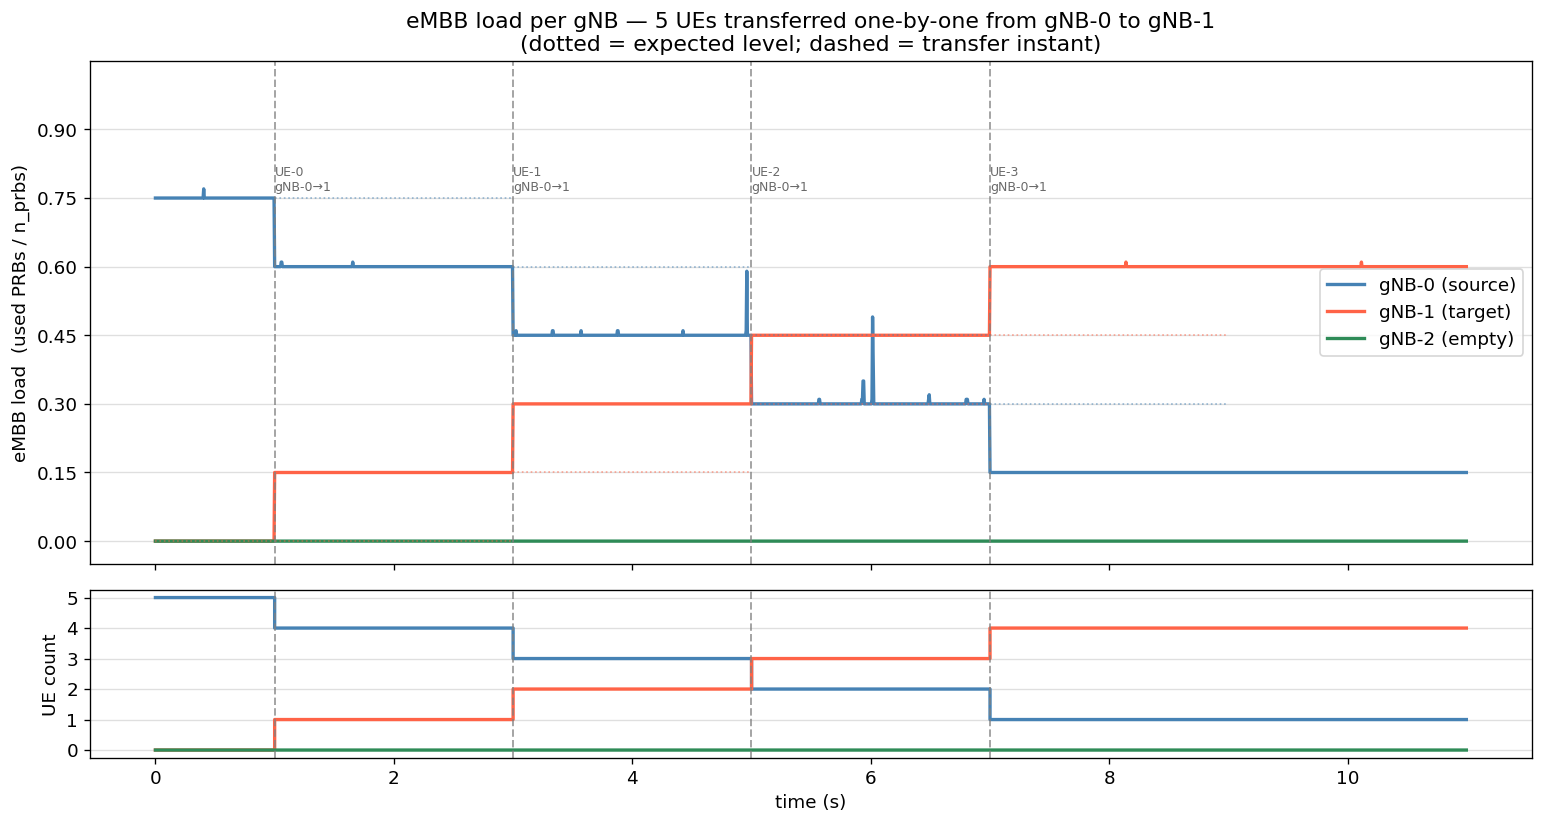

In [5]:
gnb_colors = ['steelblue', 'tomato', 'seagreen']
gnb_labels = ['gNB-0 (source)', 'gNB-1 (target)', 'gNB-2 (empty)']

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

ax_load, ax_count = axes

# ── load plot ──
for g, (color, label) in enumerate(zip(gnb_colors, gnb_labels)):
    ax_load.plot(df['time_s'], df[f'gNB{g}_eMBB'], color=color, lw=2.0, label=label)

# expected load levels (horizontal dotted references)
boundaries = [0.0, WARMUP_S] + [WARMUP_S + i * HOLD_S for i in range(1, N_TRANSFERS + 1)] + [SIMULATION_S]
for seg in range(len(boundaries) - 1):
    t0, t1 = boundaries[seg], boundaries[seg + 1]
    n_in_g0 = 5 - max(seg - 1, 0)    # 5 during warmup, then decreases by 1 each transfer
    n_in_g1 = max(seg - 1, 0)
    ax_load.hlines(n_in_g0 * 0.15, t0, t1, colors='steelblue', lw=1.0, linestyle=':', alpha=0.55)
    ax_load.hlines(n_in_g1 * 0.15, t0, t1, colors='tomato',    lw=1.0, linestyle=':', alpha=0.55)

for t, uid, src, tgt in transfer_log:
    ax_load.axvline(t, color='gray', lw=1.2, linestyle='--', alpha=0.7)
    ax_load.annotate(f'UE-{uid}\ngNB-{src}→{tgt}',
                     xy=(t, 0.82), fontsize=7.5, color='dimgray', ha='left', va='top')

ax_load.set_ylabel('eMBB load  (used PRBs / n_prbs)')
ax_load.set_ylim(-0.05, 1.05)
ax_load.set_yticks([i * 0.15 for i in range(7)])
ax_load.legend(loc='center right')
ax_load.grid(axis='y', alpha=0.4)
ax_load.set_title('eMBB load per gNB — 5 UEs transferred one-by-one from gNB-0 to gNB-1\n'
                  '(dotted = expected level; dashed = transfer instant)')

# ── UE count ──
for g, (color, label) in enumerate(zip(gnb_colors, gnb_labels)):
    ax_count.step(df['time_s'], df[f'n_g{g}'], where='post', color=color, lw=2.0, label=label)
for t, *_ in transfer_log:
    ax_count.axvline(t, color='gray', lw=1.2, linestyle='--', alpha=0.7)
ax_count.set_ylabel('UE count')
ax_count.set_xlabel('time (s)')
ax_count.set_yticks(range(6))
ax_count.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

## Verification — measured vs expected load

In [6]:
rows = []

# Warmup window: t = 0.3 s to 0.9 s (5 UEs at gNB-0, 0 at gNB-1)
warmup_w = df[(df['time_s'] >= 0.3) & (df['time_s'] < 0.9)]
if not warmup_w.empty:
    rows.append(dict(phase='warmup', ues_g0=5, ues_g1=0,
                     expected_g0=0.75, expected_g1=0.00,
                     measured_g0=round(warmup_w['gNB0_eMBB'].mean(), 3),
                     measured_g1=round(warmup_w['gNB1_eMBB'].mean(), 3)))

# Post-transfer windows
for i in range(N_TRANSFERS):
    t0 = WARMUP_S + i * HOLD_S + 0.3          # 300 ms after transfer
    t1 = WARMUP_S + (i + 1) * HOLD_S - 0.1
    w  = df[(df['time_s'] >= t0) & (df['time_s'] < t1)]
    if w.empty:
        continue
    n0 = 4 - i
    n1 = i + 1
    rows.append(dict(phase=f'after transfer {i+1}', ues_g0=n0, ues_g1=n1,
                     expected_g0=round(n0 * 0.15, 2), expected_g1=round(n1 * 0.15, 2),
                     measured_g0=round(w['gNB0_eMBB'].mean(), 3),
                     measured_g1=round(w['gNB1_eMBB'].mean(), 3)))

vdf = pd.DataFrame(rows)
vdf['err_g0'] = (vdf['measured_g0'] - vdf['expected_g0']).abs().round(3)
vdf['err_g1'] = (vdf['measured_g1'] - vdf['expected_g1']).abs().round(3)
print(vdf.to_string(index=False))

           phase  ues_g0  ues_g1  expected_g0  expected_g1  measured_g0  measured_g1  err_g0  err_g1
          warmup       5       0         0.75         0.00        0.750         0.00   0.000     0.0
after transfer 1       4       1         0.60         0.15        0.600         0.15   0.000     0.0
after transfer 2       3       2         0.45         0.30        0.450         0.30   0.000     0.0
after transfer 3       2       3         0.30         0.45        0.302         0.45   0.002     0.0
after transfer 4       1       4         0.15         0.60        0.150         0.60   0.000     0.0
